# Sampler Test

On an example ring-shaped 2D distribution we test the performance of the following sampling methods:
- rejection sampling using independent sampler to sample a prior standard normal distribution
- rejection sampling using Sobol sampler to sample a prior standard normal distribution
- random-walk Metropolis Hastings using a fixed-size isotropic mutation
- MALA using a fixed-size isotropic mutation
- Adam-adjusted MALA w/ diagonal preconditioning
- Adam-adjusted MALA w/ full preconditioning
- H2MC
- H2MC with hessian approximated by g\*g.T

Other methods that haven't been tested include:
- HMC
- NUTS
- SVGD

torch.Size([400, 400, 2])


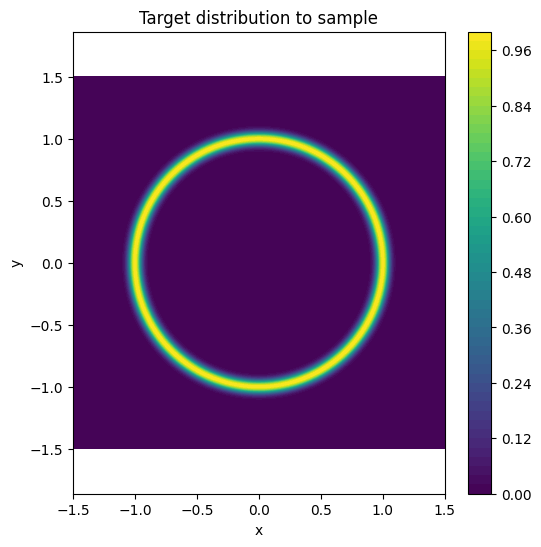

In [383]:
import numpy as np
import matplotlib.pyplot as plt
import torch

a = 400

# Define the function f(x,y)

def I(x: torch.tensor):
    r = (x**2).sum(axis=-1).sqrt()
    return r

def dI(x: torch.tensor):
    return x / (I(x)+1e-10)

def U(x: torch.tensor):
    r = I(x)
    r0 = 1
    return a * (r-r0)**2

def dU(x: torch.tensor):
    r = I(x)
    r0 = 1
    r = r.unsqueeze(-1)
    r = r.repeat(*[1]*(r.dim()-1), 2)
    c = 2*a*(r-r0)
    return c*x/(r+1e-8)


# 2d gaussian
# a = 10
# def U(x):
#     return a * (x**2).sum(axis=-1)

# def dU(x):
#     return 2*a*x


# 2d anisotropic gaussian
# a = 10
# def U(x):
#     return a * ((x*torch.tensor([0.5,10]))**2).sum(axis=-1)

# def dU(x):
#     return 2*a*x*torch.tensor([0.25,100])

# Create a meshgrid for plotting
x = np.linspace(-1.5, 1.5, 400)
y = np.linspace(-1.5, 1.5, 400)
X, Y = np.meshgrid(x, y)
p = torch.concat((torch.tensor(X).unsqueeze(axis=-1), torch.tensor(Y).unsqueeze(axis=-1)), axis=2)
print(p.shape)
Z = (-U(p)).exp().numpy()
# Z = U(p).numpy()
# Z = dU(p)[...,1].numpy()

# Plot the function
plt.figure(figsize=(6,6))
plt.contourf(X, Y, Z, 50, cmap='viridis')
plt.colorbar()
plt.title('Target distribution to sample')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

In [368]:
U(torch.randn(2))

tensor(34.0867)

In [369]:
def plot_samples(samples, opacity=0.3, title='Samples'):
    # Plot the samples
    first_half = samples[:len(samples)//2]
    second_half = samples[len(samples)//2:]

    # Plot the samples with different colors for the two halves
    plt.figure(figsize=(8, 8))
    plt.scatter(first_half[:, 0], first_half[:, 1], c='red', s=5, alpha=opacity, label='First Half')
    plt.scatter(second_half[:, 0], second_half[:, 1], c='blue', s=5, alpha=opacity, label='Second Half')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(-1.5,1.5)
    plt.ylim(-1.5,1.5)
    plt.grid(True)
    plt.show()

In [375]:
def plot_distributions(proposals):
    fig, ax = plt.subplots(figsize=(8, 8))
    def gaussian_ellipse(mean, cov, **kwargs):
        mean = mean.numpy()
        cov = cov.numpy()
        vals, vecs = np.linalg.eigh(cov)
        # Compute the angle between the x-axis and the largest eigenvector
        theta = np.degrees(np.arctan2(*vecs[:, 1][::-1])) + 90
        # Width and height of the ellipse are the square roots of the eigenvalues
        width, height = 3 * np.sqrt(vals)
        return patches.Ellipse(xy=mean, width=width, height=height, angle=theta, **kwargs)
    for distr in proposals:
        cov = distr.covariance_matrix if hasattr(distr, 'covariance_matrix') else torch.diag(distr.scale**2)
        ellipse = gaussian_ellipse(distr.loc, cov, facecolor='green', alpha=0.3)
        ax.add_patch(ellipse)

    # Adjusting the view
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    plt.grid(True)
    plt.show()

accept rate: 0.0565


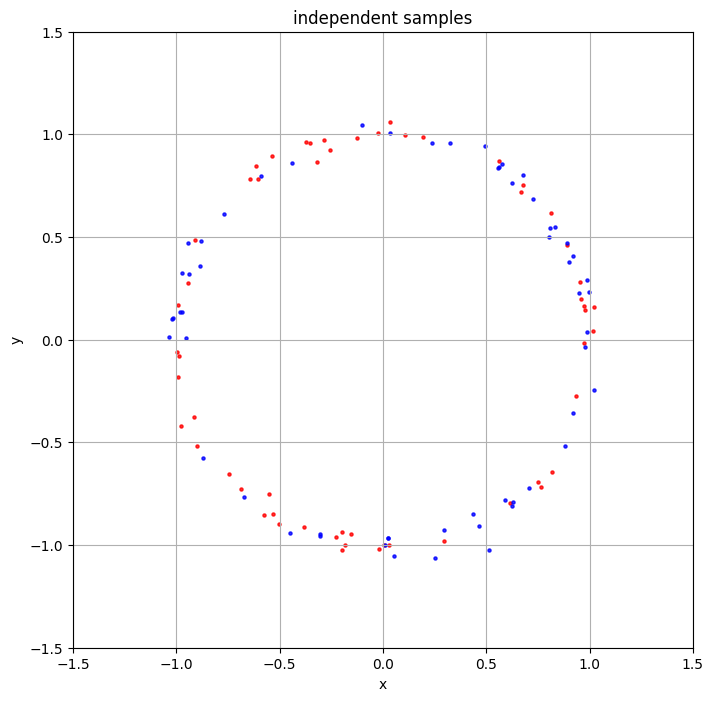

In [80]:
import math
def standard_normal_pdf(x):
    return (1 / math.sqrt(2 * math.pi)) * math.exp(-0.5 * x.norm()**2)

# sampler function
def independent_sample(x0, iterations):
    samples = []
    ps = []
    for i in range(iterations):
        x = torch.randn(x0.shape)
        samples.append(x)
        ps.append((-U(x)).exp().item() / standard_normal_pdf(x))
#         ps.append((-U(x)).exp().item() / standard_normal_pdf(x))
#     return torch.vstack(samples)
    maxp = max(ps)
    final = []
    for i in range(iterations):
        if np.random.rand() < ps[i] / maxp:
            final.append(samples[i])
    print("accept rate:", len(final) / iterations)
    return torch.vstack(final)

samples = independent_sample(torch.ones((2)), 2000)
plot_samples(samples, opacity=0.8, title="independent samples")

accept rate: 0.06


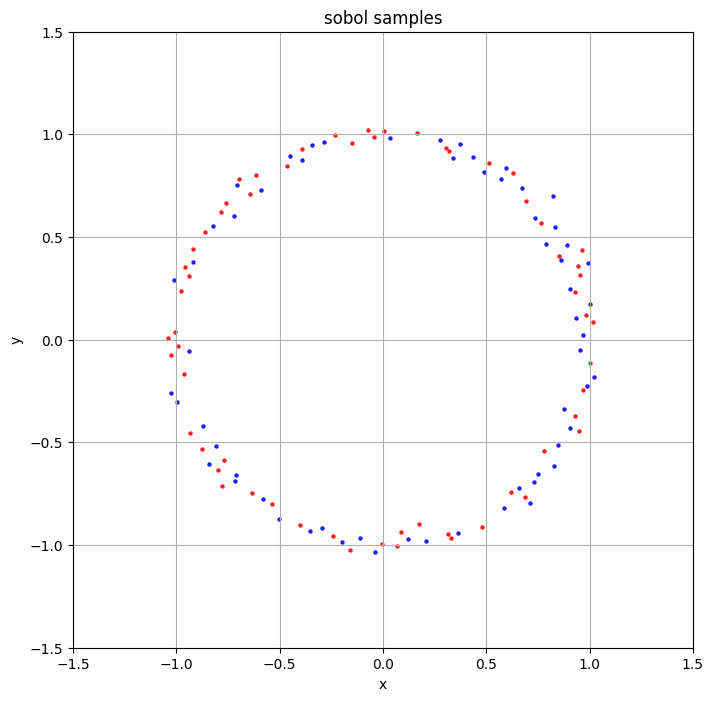

In [79]:
def inverse_cdf(samples):
    """Inverse of the CDF of the normal distribution."""
    return np.sqrt(2) * torch.erfinv(2 * samples - 1)

def sobol_sample(x0, iterations):
    # Define the dimensionality of the samples (2D in this case)
    dim = 2
    num_samples = iterations
    # Create a Sobol engine
    sobol_engine = torch.quasirandom.SobolEngine(dimension=dim, scramble=True, seed=None)
    # Get the samples
    samples = sobol_engine.draw(num_samples)
    samples = inverse_cdf(samples)
    ps = []
    for i in range(iterations):
        x = samples[i]
        ps.append((-U(x)).exp().item() / standard_normal_pdf(x))
    maxp = max(ps)
    final = []
    for i in range(iterations):
        if np.random.rand() < ps[i] / maxp:
            final.append(samples[i])
    print("accept rate:", len(final) / iterations)
    return torch.vstack(final)

samples = sobol_sample(torch.ones((2)), 2000)
plot_samples(samples, opacity=0.8, title="sobol samples")

accept rate: 0.42
avg step len: 0.09517128


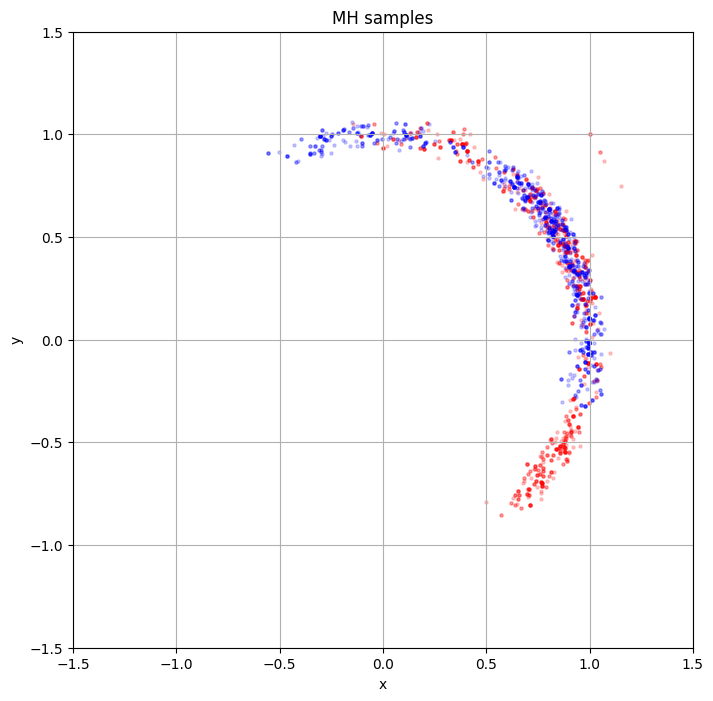

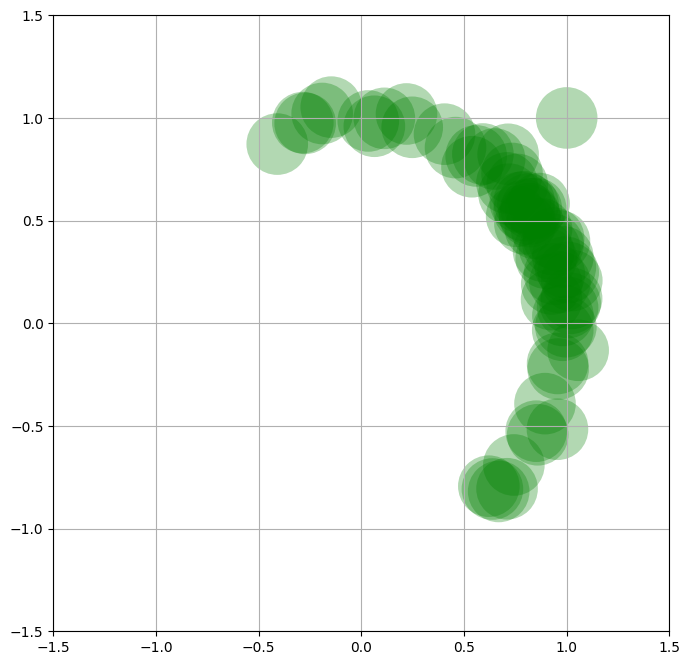

In [377]:
# Metropolis-Hastings sampler function
proposals = []
def metropolis_hastings(x0, iterations, stepsize):
    samples = [x0]
    x = x0
    num_accepts = 0
    steps = []
    
    for _ in range(iterations):
        # Propose a new point using Gaussian mutation
        x1 = x + torch.randn(x.shape) * stepsize
        proposals.append(Normal(x, stepsize))
        
        # Calculate acceptance probability
        alpha = min(1, (U(x) - U(x1)).exp())
        
        # Decide to accept or reject the proposed point
        if np.random.rand() < alpha:
            steps.append((x-x1).norm())
            x = x1
            num_accepts += 1
        
        samples.append(x)
    
    print("accept rate:", num_accepts / iterations)
    print("avg step len:", np.array(steps).mean())
    return torch.vstack(samples)

samples = metropolis_hastings(torch.ones((2)), 2000, 0.1)
plot_samples(samples, opacity=0.2, title="MH samples")
plot_distributions(proposals[::30])

num_accepts: 1864


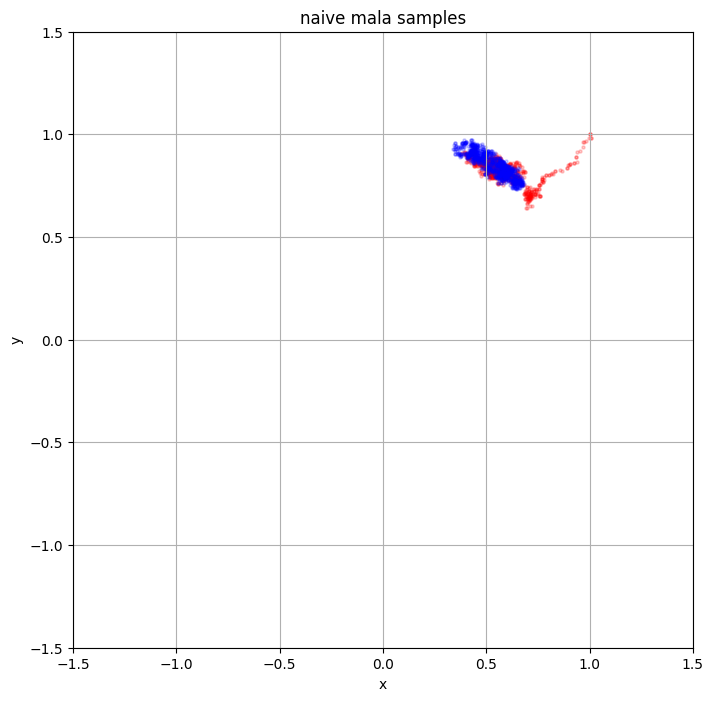

In [111]:
from torch.distributions import Normal

def mala_sampler(x0, iterations, stepsize):
    samples = [x0]
    x = x0
    num_accepts = 0
    
    for _ in range(iterations):
        # MALA proposal step
        U_this  = U(x)
        dU_this = dU(x)
        
        mu = x - 0.5 * stepsize**2 * dU_this
        sigma = stepsize
        distr = Normal(mu, sigma)
        x1 = distr.sample()
        q_this = distr.log_prob(x1).sum(dim=-1)
        
        U_tmp  = U(x1)
        dU_tmp = dU(x1)

        mu = x1 - 0.5 * stepsize**2 * dU_tmp
        sigma = stepsize
        distr = Normal(mu, sigma)
        q_tmp = distr.log_prob(x).sum(dim=-1) # pdf of reverse sample
        
#         print(U_this - U_tmp, ' vs ', q_tmp - q_this)
        arej = torch.exp((U_this-U_tmp).clamp(max=88)) * q_tmp / (q_this + 1e-8)
        alpha = min(1, arej)
        
        # Decide to accept or reject the proposed point
        if np.random.rand() < alpha:
            x = x1
            num_accepts += 1
        
        samples.append(x)
    
    print("num_accepts:", num_accepts)
    return torch.vstack(samples)

samples = mala_sampler(torch.ones((2)), 2000, 0.01)
plot_samples(samples, opacity=0.2, title="naive mala samples")

acceptance rate: 1993 / 2000 (99.65%)
avg step len: 0.014230504


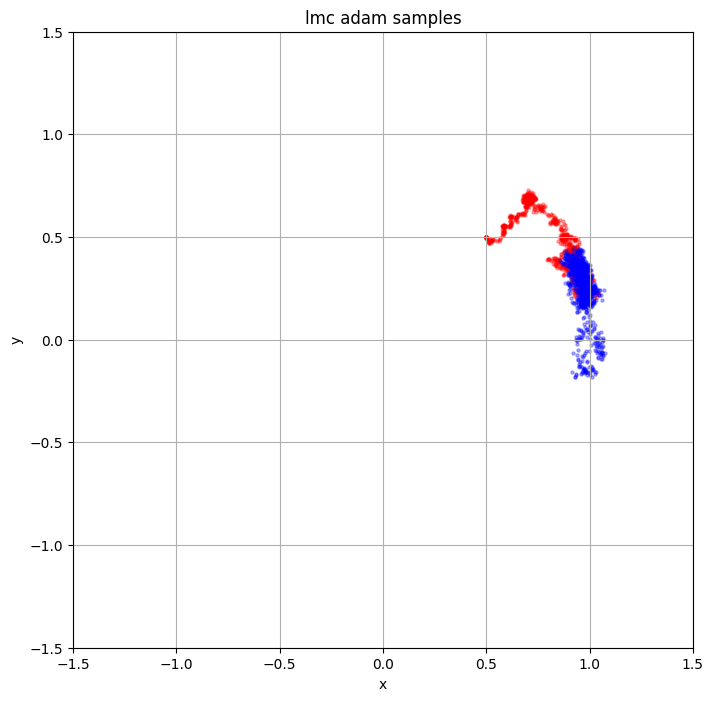

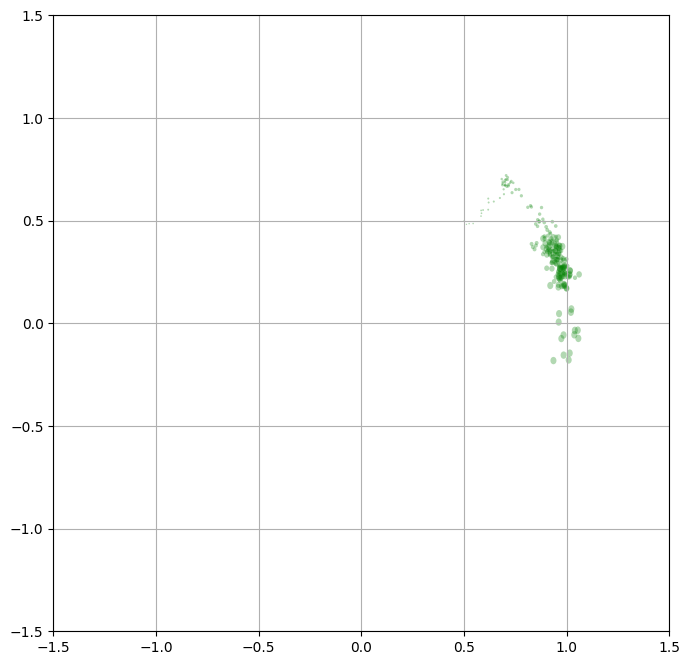

In [114]:
from torch.distributions import Normal
import matplotlib.patches as patches

proposals = []

def mala_adam(x0, iterations, lr=0.01):
#     lr = lr**2
    c1 = 0.25
    c2 = 0.25
    V1 = torch.zeros_like(x0)
    V2 = torch.zeros_like(x0)
    V1c = torch.zeros_like(x0) # initial correction for moving average
    V2c = torch.zeros_like(x0) # initial correction for moving average
    alpha = 0.9
    beta = 0.999
    eps = 1e-8
    num_accepts = 0
    samples = []
    steps = []
    
    def proposal_distro_yu(x, g):
        V10_t = alpha * V1 + (1-alpha) * g
        V20_t = beta  * V2 + (1-beta)  * g**2
        V10   = V10_t / V1c
        V20   = V20_t / V2c
#         V10 = g
#         V20 = g**2
        M1  = max(eps, num_accepts)**-c1 * V10 + g
        M2  = 1/(eps + max(eps, num_accepts)**-c2 * (V20).clamp(min=eps).sqrt())
        mu = x0 - 0.5 * lr * M1 * M2
        sigma2 = lr * M2
        sigma = sigma2.clamp(min=eps).sqrt()
        return Normal(mu, sigma), V10_t, V20_t
        
    def proposal_distro(x, g):
        V10_t = alpha * V1 + (1-alpha) * g
        V20_t = beta  * V2 + (1-beta)  * g**2
        V10   = V10_t / V1c
        V20   = V20_t / V2c
#         V10 = g
#         V20 = g**2
        M  = 1e-2 + 1/(1e-7 + V20.clamp(min=eps).sqrt())
        M = torch.ones(2)
        mu = x - 0.5 * lr * M * V10
        sigma2 = lr * M
        sigma = sigma2.clamp(min=eps).sqrt()
#         print("propose ", mu, sigma)
        return Normal(mu, sigma), V10_t, V20_t
    
    proposal_distro = proposal_distro_yu
    
    def small_step():
        U0  = U(x0)
        # update bias correction in moving average
        nonlocal V1, V2, V1c, V2c
        V1c = 1 - alpha*(1-V1c)
        V2c = 1 - beta*(1-V2c)
        # proposal
        distr0, V10, V20 = proposal_distro(x0, dU(x0))
        x1 = distr0.sample()
        proposals.append(distr0)
        q0 = distr0.log_prob(x1).sum(dim=-1) # pdf
        # reverse
        U1  = U(x1)
        distr1, _, _ = proposal_distro(x1, dU(x1))
        q1 = distr1.log_prob(x0).sum(dim=-1) # pdf
        
        arej = torch.exp((U0-U1+q1-q0).clamp(max=88))
        # update momenta
        V1 = V10
        V2 = V20
        return x1, arej
    
    def large_step():
        distr = Normal(torch.zeros(2), 1)
        x1 = distr.sample()
        U0  = U(x0)
        U1  = U(x1)
        q0 = distr.log_prob(x1).sum(dim=-1) # pdf
        q1 = distr.log_prob(x0).sum(dim=-1) # pdf
        arej = torch.exp((U0-U1+q1-q0).clamp(max=88))
        return x1, arej
        
    for it in range(iterations):
        P_LARGESTEP = 0.00
        if np.random.rand() < P_LARGESTEP:
            x1, arej = large_step()
        else:
            x1, arej = small_step()
        if np.random.rand() < min(1, arej):
            steps.append((x0-x1).norm())
            num_accepts += 1
            x0 = x1
#         print("A:", arej)
#         print()
        samples.append(x0)
    print("acceptance rate:", num_accepts, '/', iterations, f'({num_accepts/iterations*100:2}%)')
    print("avg step len:", np.array(steps).mean())
    return torch.vstack(samples)
    
        
x0 = torch.tensor([0.5, 0.5])
samples = mala_adam(x0, 2000, lr=0.001)
plot_samples(samples.numpy(), opacity=0.3, title="lmc adam samples")


# plt.figure(figsize=(8, 8))
fig, ax = plt.subplots(figsize=(8, 8))

for i, distr in enumerate(proposals[::10]):
    ellipse = patches.Ellipse(distr.loc, width=2*distr.scale[0], height=2*distr.scale[1], facecolor='green', alpha=0.3)
    ax.add_patch(ellipse)
    # point
#     ellipse = patches.Ellipse(samples[i-1] if i>0 else x0, width=0.05, height=0.05, facecolor='blue', alpha=1.0)
#     ax.add_patch(ellipse)
    

# Adjusting the view
ax.set_aspect('equal', 'box')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

plt.grid(True)
plt.show()
    

acceptance rate: 1706 / 2000 (85.3%)
avg step len: 0.017532216


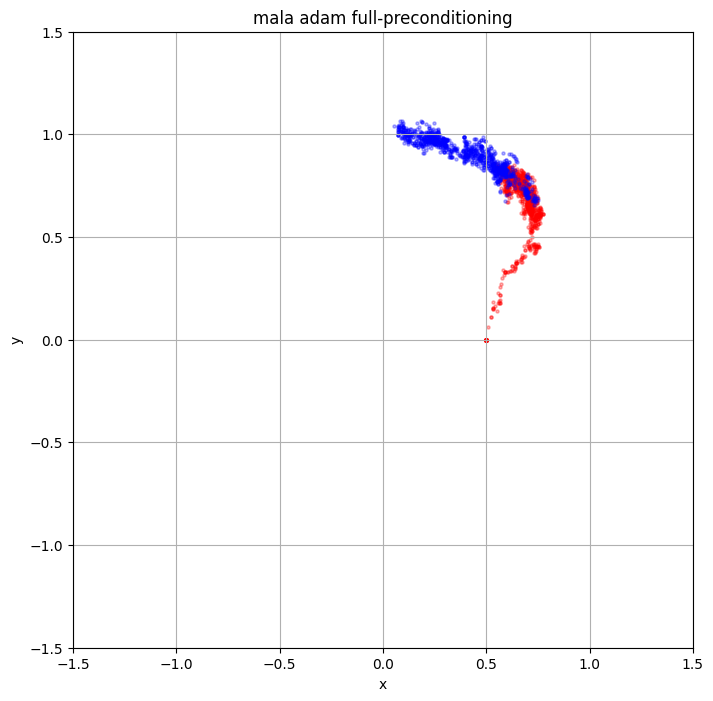

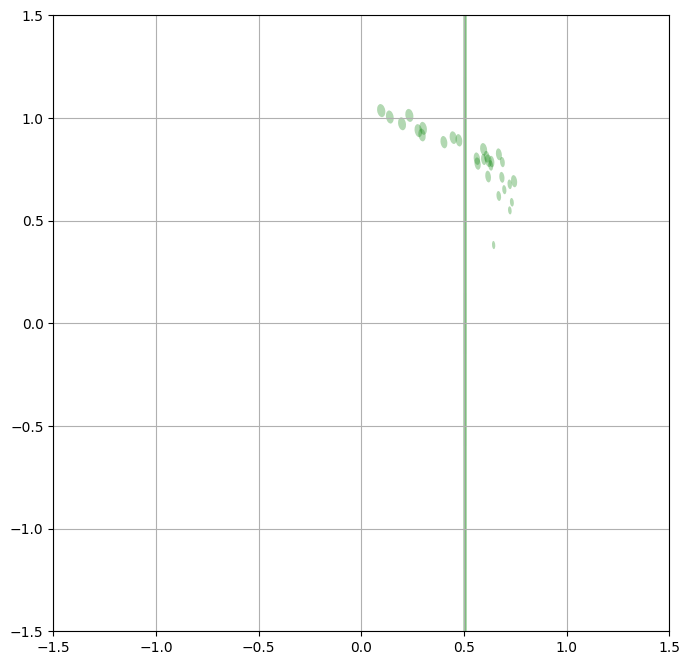

In [306]:
from torch.distributions import MultivariateNormal
import matplotlib.patches as patches

def matsqrt(g):
    eigenvalues, eigenvectors = torch.linalg.eigh(g)
    eigenvalues = eigenvalues.clamp(min=1e-7)
    sqrt_lambda = torch.diag(torch.sqrt(eigenvalues))
    sqrt_g = torch.mm(torch.mm(eigenvectors, sqrt_lambda), eigenvectors.t())
    return sqrt_g
    
proposals = []

def mala_adam_full_precondition(x0, iterations, lr):
    V1 = torch.zeros_like(x0)
    V2 = torch.zeros_like(x0.outer(x0))
    V1c = 0 # initial correction for moving average
    V2c = 0 # initial correction for moving average
    alpha = 0.9
    beta = 0.999
    eps = 1e-8
    num_accepts = 0
    samples = []
    steps = []
        
    def proposal_distro(x, g):
        V10_t = alpha * V1 + (1-alpha) * g
        V20_t = beta  * V2 + (1-beta)  * g.outer(g)
        V10   = V10_t / V1c
        V20   = V20_t / V2c
        H = eps * torch.eye(x.shape[-1]) + matsqrt(V20)
        M  = torch.inverse(H)
        mu = x - 0.5 * lr * M @ V10
        cov = lr * M
        return MultivariateNormal(mu, cov), V10_t, V20_t
    
#     proposal_distro = proposal_distro_yu
    
    def small_step():
#         print(f'x0={x0}')
        U0  = U(x0)
        # update bias correction in moving average
        nonlocal V1, V2, V1c, V2c
        V1c = 1 - alpha*(1-V1c)
        V2c = 1 - beta*(1-V2c)
        # proposal
        distr0, V10, V20 = proposal_distro(x0, dU(x0))
        x1 = distr0.sample()
        proposals.append(distr0)
        q0 = distr0.log_prob(x1).sum(dim=-1) # pdf
        # reverse
        U1  = U(x1)
        distr1, _, _ = proposal_distro(x1, dU(x1))
        q1 = distr1.log_prob(x0).sum(dim=-1) # pdf
        
        arej = torch.exp((U0-U1+q1-q0).clamp(max=88))
#         print("A:", arej)
        # update momenta
        V1 = V10
        V2 = V20
        return x1, arej
    
    def large_step():
        distr = Normal(torch.zeros(2), 1)
        x1 = distr.sample()
        U0  = U(x0)
        U1  = U(x1)
        q0 = distr.log_prob(x1).sum(dim=-1) # pdf
        q1 = distr.log_prob(x0).sum(dim=-1) # pdf
        arej = torch.exp((U0-U1+q1-q0).clamp(max=88))
        return x1, arej
        
    for it in range(iterations):
        P_LARGESTEP = 0.00
        if np.random.rand() < P_LARGESTEP:
            x1, arej = large_step()
        else:
            x1, arej = small_step()
        if np.random.rand() < min(1, arej):
            steps.append((x0-x1).norm())
            num_accepts += 1
            x0 = x1
#         print("A:", arej)
#         print()
        samples.append(x0)
    print("acceptance rate:", num_accepts, '/', iterations, f'({num_accepts/iterations*100:2}%)')
    print("avg step len:", np.array(steps).mean())
    return torch.vstack(samples)
    
        
x0 = torch.tensor([0.5, 0.0])
samples = mala_adam_full_precondition(x0, 2000, lr=0.01)
plot_samples(samples.numpy(), opacity=0.3, title="mala adam full-preconditioning")


# plt.figure(figsize=(8, 8))
fig, ax = plt.subplots(figsize=(8, 8))

def gaussian_ellipse(mean, cov, **kwargs):
    mean = mean.numpy()
    cov = cov.numpy()
    vals, vecs = np.linalg.eigh(cov)
    # Compute the angle between the x-axis and the largest eigenvector
    theta = np.degrees(np.arctan2(*vecs[:, 1][::-1])) + 90
    # Width and height of the ellipse are the square roots of the eigenvalues
    width, height = 3 * np.sqrt(vals)
    return patches.Ellipse(xy=mean, width=width, height=height, angle=theta, **kwargs)

    
for i, distr in enumerate(proposals[::len(proposals)//30]):
    ellipse = gaussian_ellipse(distr.loc, distr.covariance_matrix, facecolor='green', alpha=0.3)
    ax.add_patch(ellipse)

# Adjusting the view
ax.set_aspect('equal', 'box')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

plt.grid(True)
plt.show()

In [215]:
x = torch.randn(2)
def fd_g(x):
    h = 1e-4
    N = x.shape[-1]
    g = torch.zeros(N)
    delta = torch.eye(N) * h
    for i in range(N):
        t = U(x.add(delta[i]))
        print(g[i].shape, t.shape)
        g[i] = (U(x.add(delta[i])) - U(x.add(-delta[i]))) / (2*h)
    return g
x1 = dU(x)
x2 = fd_g(x)
x1-x2


torch.Size([]) torch.Size([])
torch.Size([]) torch.Size([])


tensor([0.0097, 0.0456])

In [388]:
# H2MC

def fd_hessian(x):
    h = 1e-3
    N = x.shape[-1]
    hess = torch.zeros((N, N))
    delta = torch.eye(N) * h
    for i in range(N):
        for j in range(N):
            hess[i][j] = \
                (dU(x.add(delta[j]))[i] - dU(x.add(-delta[j]))[i]) / (4*h) + \
                (dU(x.add(delta[i]))[j] - dU(x.add(-delta[i]))[j]) / (4*h)
    return hess

def fake_H(x: torch.tensor):
    t = dI(x)
    return 2 * a * t.outer(t)

from torch.distributions import MultivariateNormal

class GaussianComputer:
    def __init__(self):
        self.L = math.pi / 2
        self.sigma = 0.3
        self.dim = 2
        self.epsilon = 1e-8
        self.posScaleFactor = 0.5 * (np.exp(self.L) - np.exp(-self.L)) ** 2
        self.posOffsetFactor = 0.5 * (np.exp(self.L) + np.exp(-self.L) - 1)
        self.negScaleFactor = np.sin(self.L) ** 2
        self.negOffsetFactor = -(np.cos(self.L) - 1)
    
    def compute_gaussian(self, x, grad, hess):
        sigma = torch.full((self.dim,), self.sigma)
        sigma_sq = sigma * sigma
        inv_sigma_sq = 1 / sigma_sq
        if hess.norm() < 0.5 / (self.sigma ** 2):
            return MultivariateNormal(
                loc=x,
                covariance_matrix=torch.eye(self.dim) * (sigma**2)
            )
        
        eig_values, eig_vectors = torch.linalg.eig(hess)
        eig_values = eig_values.real
        eig_vectors = eig_vectors.real
        
        eigen_buff = torch.zeros(self.dim)
        offset_buff = torch.zeros(self.dim)
        post_inv_cov_eigenvalues = torch.zeros(self.dim)
        
        for i in range(self.dim):
            eigen_buff[i] = 1 / abs(eig_values[i]) if abs(eig_values[i]) > self.epsilon else 0
        
        offset_buff = torch.diag(eigen_buff) @ eig_vectors.T @ grad
#         print("offset buff:", offset_buff)
        
        for i in range(self.dim):
            scale = 1.0
            offset = 0.0
            if abs(eig_values[i]) > self.epsilon:
                offset = offset_buff[i]
                scale = self.posScaleFactor if eig_values[i] > 0.0 else self.negScaleFactor
                offset *= self.posOffsetFactor if eig_values[i] > 0.0 else self.negOffsetFactor
            else:
                scale = self.L ** 2
                offset = 0.5 * offset_buff[i] * self.L ** 2
            eigen_buff[i] *= scale
            eigen_buff[i] = 1 / eigen_buff[i] if eigen_buff[i] > self.epsilon else 0.0
            offset_buff[i] = offset
        
        post_inv_cov_eigenvalues = eigen_buff + inv_sigma_sq
        offset = eig_vectors @ np.diag(eigen_buff / post_inv_cov_eigenvalues) @ offset_buff
        covL = eig_vectors @ np.diag(1 / post_inv_cov_eigenvalues.sqrt())
        
        # clamp offset to make it not go too far
#         print("offset:", offset.norm())
        if (offset.norm() > self.sigma):
            offset *= (sigma)/offset.norm()
         
        return MultivariateNormal(
            loc = x + offset,
            covariance_matrix = covL @ covL.T
            )

tensor([0.8660, 0.5000]) tensor([[ 0.0234, -0.0384],
        [-0.0384,  0.0678]])
tensor([1., 0.]) tensor([[0.0012, 0.0000],
        [0.0000, 0.0900]])
tensor([-0.9986,  0.0000]) tensor([[0.0012, 0.0000],
        [0.0000, 0.0900]])
tensor([0.7070, 0.7070]) tensor([[ 0.0456, -0.0444],
        [-0.0444,  0.0456]])
tensor([-0.8330,  0.5553]) tensor([[0.0285, 0.0410],
        [0.0410, 0.0627]])
tensor([0.9959, 0.0000]) tensor([[0.0012, 0.0000],
        [0.0000, 0.0900]])


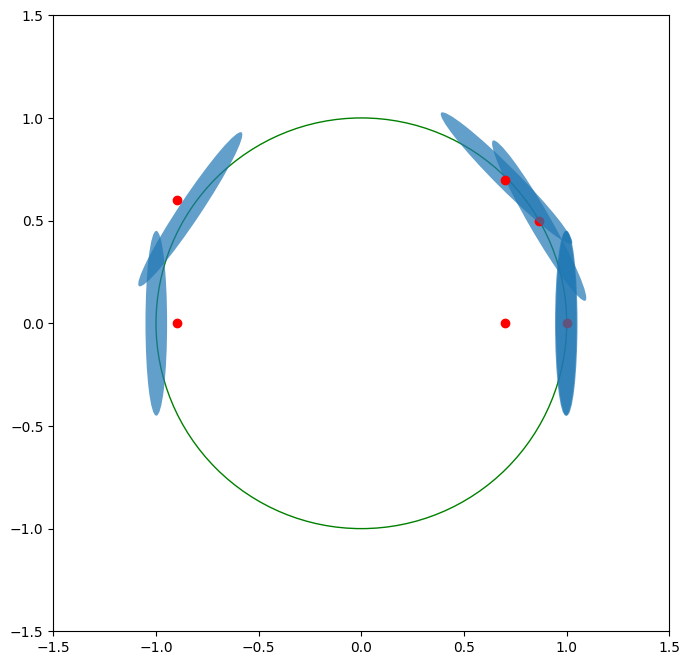

In [389]:
propose_distribution = GaussianComputer().compute_gaussian


fig, ax = plt.subplots(figsize=(8, 8))
circle1 = plt.Circle((0, 0), 1, color='green', fill=False)
ax.add_patch(circle1)

def pltgaussian(x):
    distr = propose_distribution(x, -dU(x), -fake_H(x))
#     distr = propose_distribution(x, -dU(x), -fd_hessian(x))
    print(distr.loc, distr.covariance_matrix)
    elli = gaussian_ellipse(distr.loc, distr.covariance_matrix, alpha=0.7)
    ax.add_patch(elli)
    ax.scatter([x[0]], [x[1]], c='red')
    
pltgaussian(torch.tensor([math.sqrt(3)/2, 0.5]))
pltgaussian(torch.tensor([1.0, 0]))
pltgaussian(torch.tensor([-0.9, 0]))
pltgaussian(torch.tensor([0.7, 0.7]))
pltgaussian(torch.tensor([-0.9, 0.6]))
pltgaussian(torch.tensor([0.7, 0.0]))


# Adjusting the view
ax.set_aspect('equal', 'box')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
# plt.grid(True)
plt.show()


acceptance rate: 1185 / 2000 (59.25%)
avg step len: 0.14415006


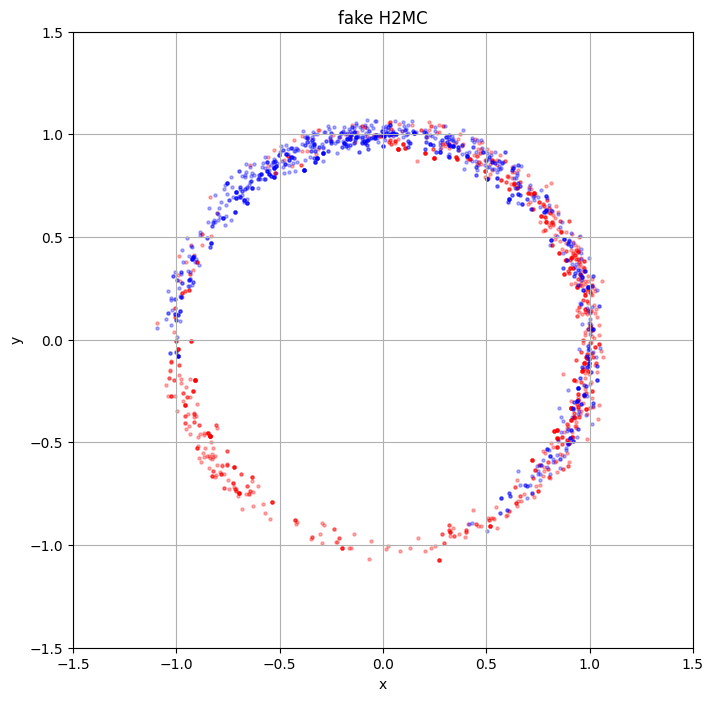

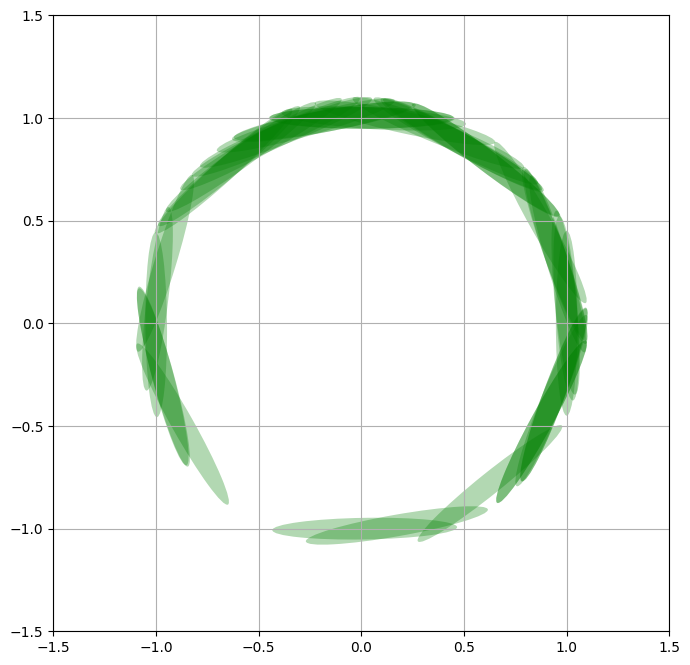

In [397]:
proposals = []

def H2MC(x0, iterations):
    num_accepts = 0
    samples = []
    steps = []
        
    proposal_distro = GaussianComputer().compute_gaussian
    
    def small_step():
        U0  = U(x0)
        # proposal
        distr0 = proposal_distro(x0, -dU(x0), -fake_H(x0))
        proposals.append(distr0)
        x1 = distr0.sample()
        proposals.append(distr0)
        q0 = distr0.log_prob(x1).sum(dim=-1) # pdf
        # reverse
        U1  = U(x1)
        distr1 = proposal_distro(x1, -dU(x1), -fake_H(x1))
        q1 = distr1.log_prob(x0).sum(dim=-1) # pdf
        
        arej = torch.exp((U0-U1+q1-q0).clamp(max=88))
        return x1, arej
    
    def large_step():
        distr = Normal(torch.zeros(2), 1)
        x1 = distr.sample()
        U0  = U(x0)
        U1  = U(x1)
        q0 = distr.log_prob(x1).sum(dim=-1) # pdf
        q1 = distr.log_prob(x0).sum(dim=-1) # pdf
        arej = torch.exp((U0-U1+q1-q0).clamp(max=88))
        return x1, arej
        
    for it in range(iterations):
        P_LARGESTEP = 0.00
        if np.random.rand() < P_LARGESTEP:
            x1, arej = large_step()
        else:
            x1, arej = small_step()
        if np.random.rand() < min(1, arej):
            steps.append((x0-x1).norm())
            num_accepts += 1
            x0 = x1
#         print("A:", arej)
        samples.append(x0)
    print("acceptance rate:", num_accepts, '/', iterations, f'({num_accepts/iterations*100:2}%)')
    print("avg step len:", np.array(steps).mean())
    return torch.vstack(samples)


x0 = torch.tensor([1.0, 0.0])
samples = H2MC(x0, 2000)
plot_samples(samples.numpy(), opacity=0.3, title="fake H2MC")
plot_distributions(proposals[::100])

In [243]:
fake_H(torch.tensor([math.sqrt(3)/2, 0.5]))

tensor([[600.0000, 346.4102],
        [346.4102, 200.0000]])

In [244]:
fd_hessian(torch.tensor([math.sqrt(3)/2, 0.5]))

tensor([[599.9999, 346.3976],
        [346.3976, 199.9855]])

In [127]:
from statsmodels.tsa.stattools import acf

def plot_acf(samples, extended_lags = 2000):
    # Extend the lag range for the autocorrelation
    acf_x_extended = acf(samples[:, 0], nlags=extended_lags, fft=True)
    acf_y_extended = acf(samples[:, 1], nlags=extended_lags, fft=True)

    # Plot the extended autocorrelation
    fig, axes = plt.subplots(2, 1, figsize=(7,7))

    axes[0].plot(range(extended_lags+1), acf_x_extended, marker='o', linestyle='-', color='blue')
    axes[0].axhline(y=0, color='black', linestyle='--')
    axes[0].axhline(y=-1.96/np.sqrt(len(samples)), color='red', linestyle='--')
    axes[0].axhline(y=1.96/np.sqrt(len(samples)), color='red', linestyle='--')
    axes[0].set_title('Extended Autocorrelation for x-coordinate')
    axes[0].set_xlabel('Lag')
    axes[0].set_ylabel('Autocorrelation')

    axes[1].plot(range(extended_lags+1), acf_y_extended, marker='o', linestyle='-', color='blue')
    axes[1].axhline(y=0, color='black', linestyle='--')
    axes[1].axhline(y=-1.96/np.sqrt(len(samples)), color='red', linestyle='--')
    axes[1].axhline(y=1.96/np.sqrt(len(samples)), color='red', linestyle='--')
    axes[1].set_title('Extended Autocorrelation for y-coordinate')
    axes[1].set_xlabel('Lag')
    axes[1].set_ylabel('Autocorrelation')

    plt.tight_layout()
    plt.show()
    print(sum(acf_x_extended))
    return 1 + 2 * sum(acf_x_extended)

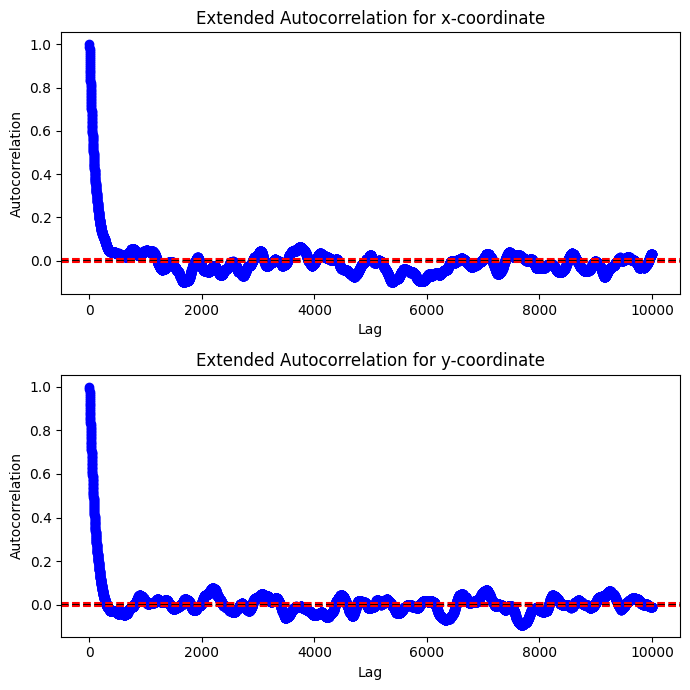

-49.88874530774504


-98.77749061549008

In [48]:
plot_acf(samples[10000:80000], 10000)